# Generate Sit-to-Stand Cam (No Optimization)

A lightweight companion to [generate_cams_si2st.ipynb](generate_cams_si2st.ipynb)
that generates a single sit-to-stand (si2st) cam design from a manually
specified set of gear ratios, input angles, and a scaling factor, using
`CamGeneration` from [class_cam_generation.py](class_cam_generation.py) —
without running the multi-objective optimization search.

Useful for quickly testing a specific design or iterating on
`class_cam_generation.py` (via `reload`) without the cost of a full
optimization run.

**Outputs:** cam plots, the resulting peak force/percentage/radius/sitting-force
summary printed to output, and optionally saved cam point clouds under
`results/cams/cams_<date>/`.

In [4]:
from importlib import reload
from datetime import date
from pathlib import Path

import numpy as np

import class_cam_generation
from class_cam_generation import CamGeneration

# Define problem parameters. Forces are in Newtons, lengths are in meters.
user_height = 1.654 # avg. height of subjects 55+ in NHANES 2017-2020
k = 100 # N/m
sit_angle_deg = 220 # degrees
offset_angle_deg = 180 # degrees
target_force_max = 100 # N
target_percentage_max = 32.5 # %
target_sitting_max = 12.5 # N
target_r_max = 0.0635 # m
dateStr = date.today().strftime("%Y-%m-%d")

In [5]:
def generate_cam(x, plot=False, save=False, index=0, save_dir=None):
    """ Generates a cam from the given gear ratios, input angles, and scaling.
    """
    gear_ratios = x[: 8]
    input_angles = x[8 : -1]
    scaling = x[-1]

    # Generate a Cam object with the given parameters.
    Cam = CamGeneration(gear_ratios, input_angles, scaling,
                        sit_angle=np.deg2rad(sit_angle_deg),
                        offset_angle=np.deg2rad(offset_angle_deg))

    # Calculate the cam radii and points for the generated cam.
    cam_radii, pts_trans, pts_stor, r_max, x_cable = Cam.calculate_cam_radii(
        user_height, k, plot=plot, save=save, save_dir=save_dir, index=index)

    # Obtain the forces and stance percentages for the generated cams.
    forces, percentages = Cam.calc_forces(cam_radii, x_cable, k, torque=False,
                                              plot=plot, save=save, 
                                              save_dir=save_dir, index=index)

    # Obtain the objective values for the given cams.
    f_max = max(forces)
    perc_f_max = percentages[np.where(forces == f_max)[0][0]]
    perc_sitting_ind = np.where(np.round(percentages, 1) == 0)[0][0]
    f_sit = forces[perc_sitting_ind]

    if save:
        p = Path('results/cams/cams_' + dateStr)
        p.mkdir(parents=True, exist_ok=True)
        dir_si2st = p / 'cam_pts_trans_si2st'
        dir_stor = p / 'cam_pts_stor'
        dir_si2st.mkdir(parents=True, exist_ok=True)
        dir_stor.mkdir(parents=True, exist_ok=True)
        file_si2st = dir_si2st / f'trans_si2st_{index}.txt'
        file_stor = dir_stor / f'stor_{index}.txt'

        np.savetxt(str(file_si2st),
                    np.append(pts_trans * 1000, 
                                np.zeros((pts_trans.shape[0], 1)), axis=1), 
                    delimiter=',')
        np.savetxt(str(file_stor),
                    np.append(pts_stor * 1000,
                                np.zeros((pts_stor.shape[0], 1)), axis=1),
                    delimiter=',')

    return r_max, perc_f_max, f_max, f_sit

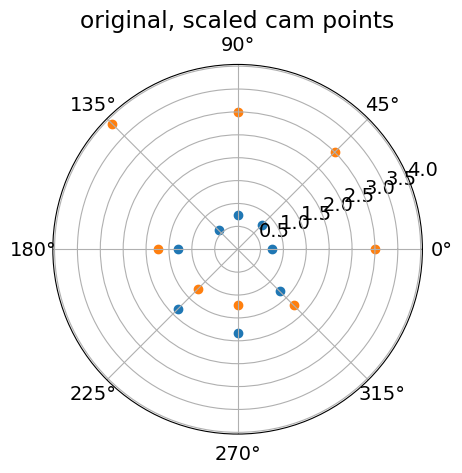

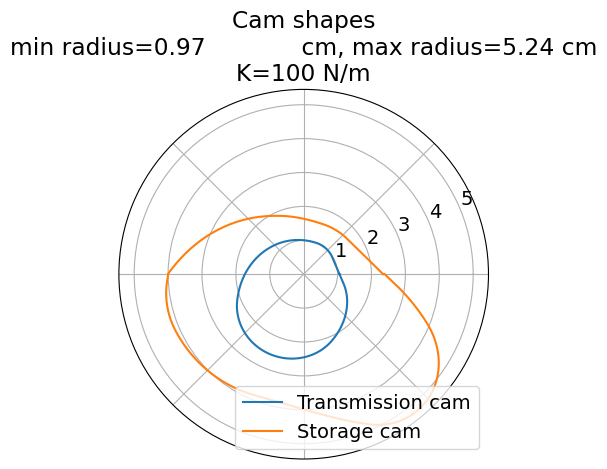

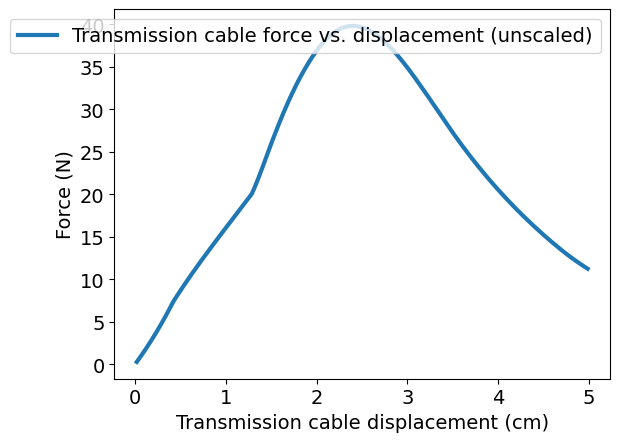

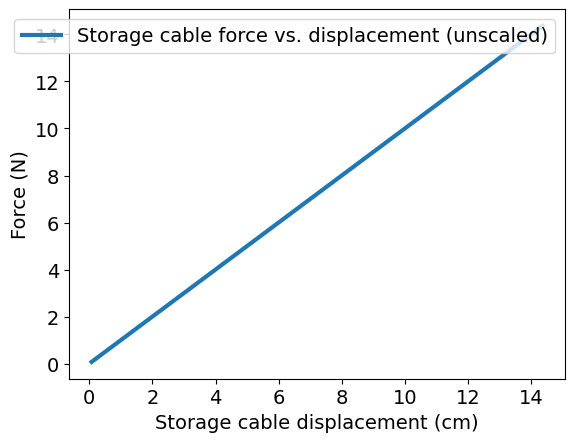

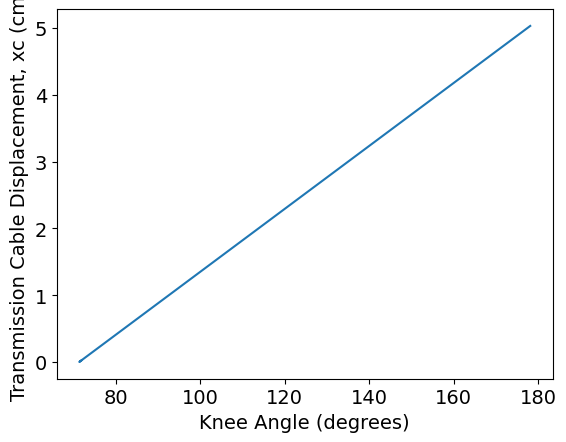

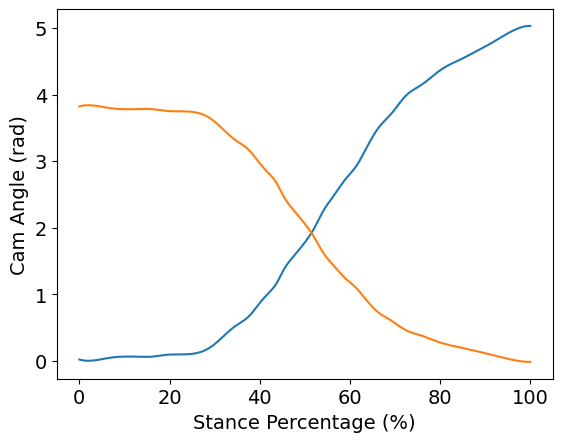

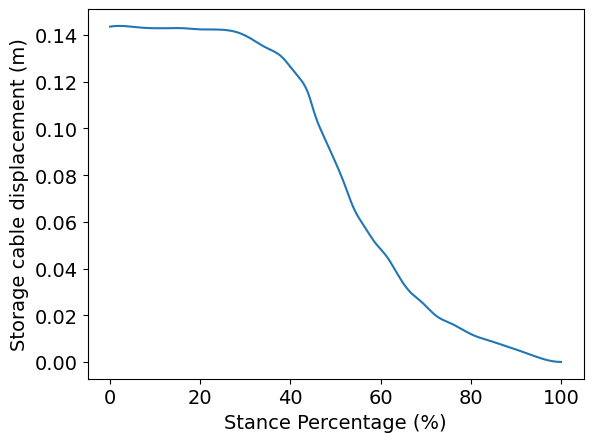

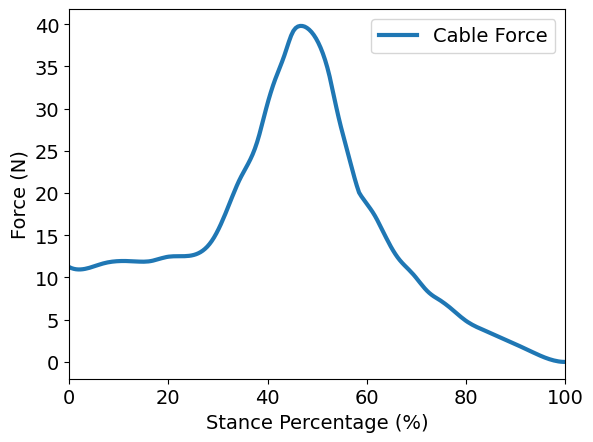

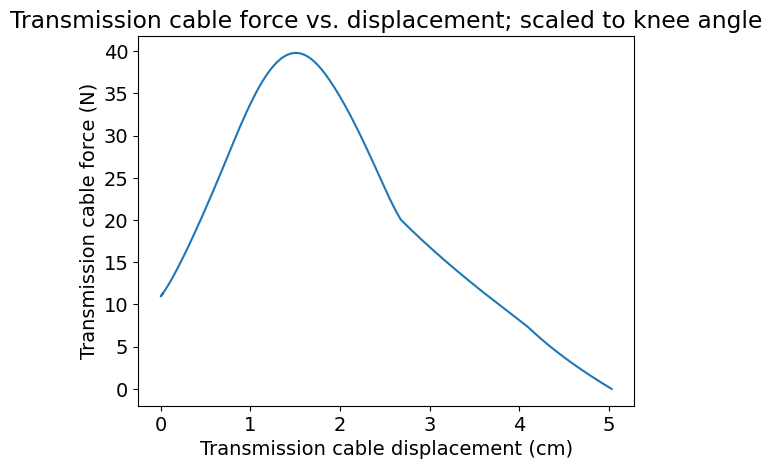

Peak force: 39.79 N at 46.58%
Max radius: 0.05 cm
Sitting force: 11.23 N
Total error: 85.57


In [6]:
# Reload the class_cam_generation module to get the latest version of
# the code (useful while editing the other file).
reload(class_cam_generation)
from class_cam_generation import CamGeneration

# INPUT: Define cam parameters.
gear_ratios = np.array([0.25, 0.25, 0.25, 0.15, 0.75, 1.5, 1.5, 0.75])
input_angles = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4,
                         3*np.pi/2, 7*np.pi/4])
scaling = np.array([1.5])

# Combine all input parameters into a single array.
x = np.append(np.append(gear_ratios, input_angles), scaling)

# Generate cam and calculate objective values.
r_max, perc_force_max, f_max, f_sit = generate_cam(x, plot=True, save=True)
error_total = (r_max
                + abs(perc_force_max - target_percentage_max)
                + abs(f_max - target_force_max)
                + abs(f_sit)
                )

print(f'Peak force: {f_max:.2f} N at {perc_force_max:.2f}%')
print(f'Max radius: {r_max:.2f} cm')
print(f'Sitting force: {f_sit:.2f} N')
print(f'Total error: {error_total:.2f}')